
### Module 1: Machine Learning Pipeline &nbsp;|&nbsp; Module 2: Supervised Learning

---
## Agenda

**Module 1 — Machine Learning Pipeline**
1. Data Preprocessing (cleaning, encoding, scaling, feature engineering, feature selection)
2. Exploratory Data Analysis (EDA)
3. Model Evaluation (confusion matrix, precision/recall/F1, ROC-AUC, cross-validation, hyperparameter tuning)

**Module 2 — Supervised Learning**
1. Linear Regression
2. Logistic Regression
3. Decision Trees
4. Support Vector Machines (SVM)
5. k-Nearest Neighbors (k-NN)
6. Naïve Bayes
7. Random Forest
8. Ensemble Learning (Bagging vs Boosting)


## 🔧 Setup

Run this first — it imports every library we need and fixes a random seed so results are reproducible
for everyone in the workshop.


In [17]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Synthetic data generators
from sklearn.datasets import make_classification, make_regression, make_blobs

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score, classification_report,
                              roc_curve, roc_auc_score, RocCurveDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

print("✅ Libraries loaded. Ready to go!")


✅ Libraries loaded. Ready to go!


---
# 📦 Module 1: Machine Learning Pipeline

Every ML project follows roughly the same pipeline:

`Raw data → Clean data → Explore data → Engineer/select features → Train model → Evaluate model → Tune model`

We'll build a **messy synthetic dataset on purpose** (missing values, duplicates, outliers, mixed
categorical/numeric columns) so we can practice fixing real-world problems.

## 1.1 Data Preprocessing

### Create a synthetic "messy" customer dataset

Imagine a telecom company's customer dataset used to predict **churn** (whether a customer leaves).


In [18]:
def make_messy_customer_data(n=500, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    age = rng.normal(40, 12, n).round(0)
    tenure_months = rng.integers(1, 72, n)
    monthly_charges = rng.normal(70, 25, n).round(2)
    total_charges = (monthly_charges * tenure_months) + rng.normal(0, 50, n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.25, 0.20])
    internet_service = rng.choice(["DSL", "Fiber optic", "No"], n, p=[0.35, 0.45, 0.20])
    support_calls = rng.poisson(2, n)

    # churn depends (noisily) on tenure, contract type and support calls
    churn_score = (
        -0.05 * tenure_months
        + 0.6 * (contract == "Month-to-month")
        + 0.3 * support_calls
        + rng.normal(0, 1.5, n)
    )
    churn = (churn_score > np.percentile(churn_score, 70)).astype(int)

    df = pd.DataFrame({
        "customer_id": [f"CUST{i:04d}" for i in range(n)],
        "age": age,
        "tenure_months": tenure_months,
        "monthly_charges": monthly_charges,
        "total_charges": total_charges,
        "contract": contract,
        "internet_service": internet_service,
        "support_calls": support_calls,
        "churn": churn,
    })

    # --- Inject real-world mess on purpose ---
    # 1. Missing values
    for col in ["age", "total_charges", "internet_service"]:
        missing_idx = rng.choice(df.index, size=int(0.05 * n), replace=False)
        df.loc[missing_idx, col] = np.nan

    # 2. Duplicate rows
    dup_rows = df.sample(10, random_state=seed)
    df = pd.concat([df, dup_rows], ignore_index=True)

    # 3. Outliers in monthly_charges
    outlier_idx = rng.choice(df.index, size=5, replace=False)
    df.loc[outlier_idx, "monthly_charges"] *= 6

    # 4. Inconsistent categorical text (needs cleaning)
    df["contract"] = df["contract"].replace({"Month-to-month": "month-to-month "})

    return df

df_raw = make_messy_customer_data()
print(df_raw.shape)
df_raw.head(10)


(510, 9)


,customer_id,age,tenure_months,monthly_charges,total_charges,contract,internet_service,support_calls,churn
0,CUST0000,44.0,30,99.69,2940.635428,month-to-month,DSL,2,0
1,CUST0001,28.0,27,44.48,1285.139310,Two year,DSL,4,0
2,CUST0002,49.0,51,23.50,1171.951175,month-to-month,No,5,0
3,CUST0003,51.0,11,72.48,849.523641,One year,Fiber optic,4,0
4,CUST0004,17.0,17,93.27,1588.989331,Two year,DSL,1,0
5,CUST0005,24.0,43,114.94,4921.812531,month-to-month,NaN,1,0
6,CUST0006,42.0,48,82.91,3889.295157,One year,No,1,0
7,CUST0007,36.0,9,60.71,NaN,month-to-month,NaN,1,1
8,CUST0008,NaN,37,47.67,1685.820838,month-to-month,Fiber optic,2,1
9,CUST0009,30.0,26,70.29,1875.904962,One year,DSL,0,0


### Data Cleaning

Checklist for this dataset: missing values, duplicate rows, inconsistent text, outliers.

**🧪 Try it yourself:** change the imputation strategy (`mean` → `median`) and see how it changes
`age` and `total_charges`.


In [19]:
df = df_raw.copy()

# --- 1. Inspect missingness & duplicates ---
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated(subset=df.columns.difference(["customer_id"])).sum())

# --- 2. Drop duplicates ---
df = df.drop_duplicates(subset=df.columns.difference(["customer_id"])).reset_index(drop=True)

# --- 3. Clean inconsistent text ---
df["contract"] = df["contract"].str.strip().str.lower()
df["contract"] = df["contract"].replace({"month-to-month": "Month-to-month",
                                          "one year": "One year",
                                          "two year": "Two year"})

# --- 4. Handle missing values ---
num_imputer = SimpleImputer(strategy="median")
df[["age", "total_charges"]] = num_imputer.fit_transform(df[["age", "total_charges"]])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[["internet_service"]] = cat_imputer.fit_transform(df[["internet_service"]])

# --- 5. Cap extreme outliers using the IQR rule ---
q1, q3 = df["monthly_charges"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df["monthly_charges"] = df["monthly_charges"].clip(upper=upper_bound)

print("\nShape after cleaning:", df.shape)
print("Missing values now:\n", df.isna().sum())
df.head()


Missing values per column:
 customer_id          0
age                 27
tenure_months        0
monthly_charges      0
total_charges       25
contract             0
internet_service    25
support_calls        0
churn                0
dtype: int64

Duplicate rows: 10

Shape after cleaning: (500, 9)
Missing values now:
 customer_id         0
age                 0
tenure_months       0
monthly_charges     0
total_charges       0
contract            0
internet_service    0
support_calls       0
churn               0
dtype: int64


,customer_id,age,tenure_months,monthly_charges,total_charges,contract,internet_service,support_calls,churn
0,CUST0000,44.0,30,99.69,2940.635428,Month-to-month,DSL,2,0
1,CUST0001,28.0,27,44.48,1285.139310,Two year,DSL,4,0
2,CUST0002,49.0,51,23.50,1171.951175,Month-to-month,No,5,0
3,CUST0003,51.0,11,72.48,849.523641,One year,Fiber optic,4,0
4,CUST0004,17.0,17,93.27,1588.989331,Two year,DSL,1,0


### Data Preprocessing in Python — Encoding categorical variables

Models need numbers, not text. We'll use:
- **Label Encoding** for the target (`churn` is already 0/1).
- **One-Hot Encoding** for nominal categories (`contract`, `internet_service`) since they have no natural order.


In [20]:
df_encoded = pd.get_dummies(df, columns=["contract", "internet_service"], drop_first=True)
df_encoded = df_encoded.drop(columns=["customer_id"])
df_encoded.head()


,age,tenure_months,monthly_charges,total_charges,support_calls,churn,contract_One year,contract_Two year,internet_service_Fiber optic,internet_service_No
0,44.0,30,99.69,2940.635428,2,0,False,False,False,False
1,28.0,27,44.48,1285.139310,4,0,False,True,False,False
2,49.0,51,23.50,1171.951175,5,0,False,False,False,True
3,51.0,11,72.48,849.523641,4,0,True,False,True,False
4,17.0,17,93.27,1588.989331,1,0,False,True,False,False


### Feature Scaling

`monthly_charges` and `tenure_months` are on very different scales. Many algorithms (KNN, SVM,
gradient-based models) are sensitive to this, so we standardize numeric features
(mean = 0, std = 1) using `StandardScaler`.


In [21]:
numeric_cols = ["age", "tenure_months", "monthly_charges", "total_charges", "support_calls"]

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Before scaling (mean, std):")
print(df_encoded[numeric_cols].agg(["mean", "std"]).round(2))
print("\nAfter scaling (mean, std):")
print(df_scaled[numeric_cols].agg(["mean", "std"]).round(2))


Before scaling (mean, std):
        age  tenure_months  monthly_charges  total_charges  support_calls
mean  39.81          36.14            70.55        2474.96           1.95
std   11.25          20.59            25.49        1695.53           1.43

After scaling (mean, std):
      age  tenure_months  monthly_charges  total_charges  support_calls
mean  0.0           -0.0             -0.0           -0.0            0.0
std   1.0            1.0              1.0            1.0            1.0


### Feature Engineering & Feature Extraction

We can create new, more informative features from existing ones — this is often where the biggest
accuracy gains come from, more than swapping algorithms.


In [22]:
df_fe = df_encoded.copy()

# Feature engineering: derived / interaction features
df_fe["avg_monthly_spend"] = df_fe["total_charges"] / df_fe["tenure_months"].replace(0, 1)
df_fe["is_new_customer"] = (df_fe["tenure_months"] <= 6).astype(int)
df_fe["high_support_calls"] = (df_fe["support_calls"] >= 4).astype(int)

df_fe[["tenure_months", "total_charges", "avg_monthly_spend",
       "is_new_customer", "high_support_calls"]].head()


,tenure_months,total_charges,avg_monthly_spend,is_new_customer,high_support_calls
0,30,2940.635428,98.021181,0,0
1,27,1285.139310,47.597752,0,1
2,51,1171.951175,22.979435,0,1
3,11,849.523641,77.229422,0,1
4,17,1588.989331,93.469961,0,0


### Feature Selection

More features isn't always better — irrelevant features add noise and slow training. We use
`SelectKBest` with an ANOVA F-test to rank features by how strongly they relate to `churn`.

**🧪 Try it yourself:** change `k=5` to a different number and see which features drop out.


In [23]:
X_fs = df_fe.drop(columns=["churn"])
y_fs = df_fe["churn"]

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_fs, y_fs)

scores = pd.Series(selector.scores_, index=X_fs.columns).sort_values(ascending=False)
print("Feature importance (F-scores):")
print(scores)

top_features = scores.head(5).index.tolist()
print("\nTop 5 selected features:", top_features)


Feature importance (F-scores):
tenure_months                   110.311779
total_charges                    68.659364
is_new_customer                  25.603252
support_calls                    12.560201
contract_One year                 4.795851
high_support_calls                4.220339
contract_Two year                 1.948391
internet_service_No               1.919270
age                               0.874917
monthly_charges                   0.379132
internet_service_Fiber optic      0.167516
avg_monthly_spend                 0.012118
dtype: float64

Top 5 selected features: ['tenure_months', 'total_charges', 'is_new_customer', 'support_calls', 'contract_One year']


---
## 1.2 Exploratory Data Analysis (EDA)

EDA helps us understand distributions, relationships, and anomalies **before** modeling.


In [24]:
df_fe.describe().T


,count,mean,std,min,25%,50%,75%,max
age,500.0,39.812000,11.245692,9.000000,32.000000,40.000000,46.000000,75.000000
tenure_months,500.0,36.136000,20.594022,1.000000,19.000000,36.000000,54.000000,71.000000
monthly_charges,500.0,70.551383,25.485647,-21.210000,54.197500,70.750000,85.890000,133.428750
total_charges,500.0,2474.962054,1695.528575,-411.441009,1012.848901,2270.098550,3609.108266,8237.192174
support_calls,500.0,1.952000,1.426101,0.000000,1.000000,2.000000,3.000000,7.000000
churn,500.0,0.300000,0.458717,0.000000,0.000000,0.000000,1.000000,1.000000
avg_monthly_spend,500.0,68.918053,27.504297,-38.043470,51.628111,69.907132,85.130765,252.233172
is_new_customer,500.0,0.090000,0.286468,0.000000,0.000000,0.000000,0.000000,1.000000
high_support_calls,500.0,0.150000,0.357429,0.000000,0.000000,0.000000,0.000000,1.000000


/tmp/ipykernel_1265/1936680404.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="churn", data=df_fe, ax=axes[2], palette="Set2")


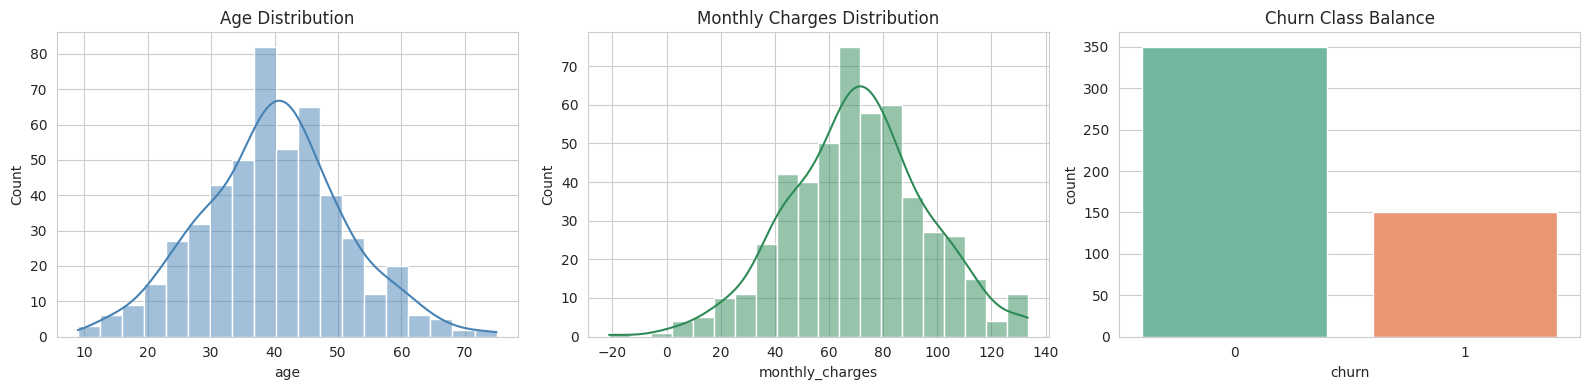

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_fe["age"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

sns.histplot(df_fe["monthly_charges"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Monthly Charges Distribution")

sns.countplot(x="churn", data=df_fe, ax=axes[2], palette="Set2")
axes[2].set_title("Churn Class Balance")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1265/1982059136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="churn", y="tenure_months", data=df_fe, ax=ax[0], palette="Set2")
/tmp/ipykernel_1265/1982059136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="churn", y="monthly_charges", data=df_fe, ax=ax[1], palette="Set2")


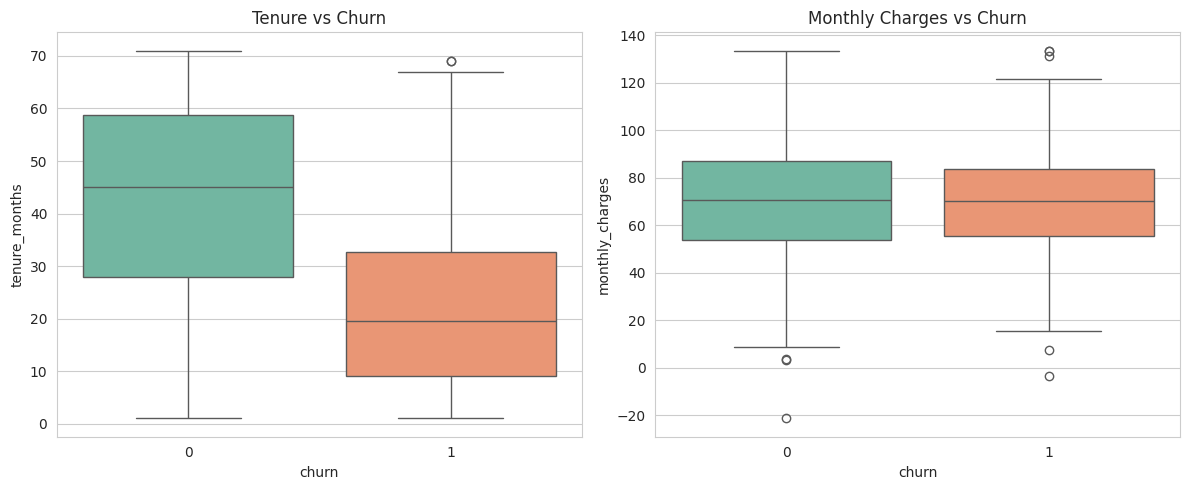

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="churn", y="tenure_months", data=df_fe, ax=ax[0], palette="Set2")
ax[0].set_title("Tenure vs Churn")

sns.boxplot(x="churn", y="monthly_charges", data=df_fe, ax=ax[1], palette="Set2")
ax[1].set_title("Monthly Charges vs Churn")
plt.tight_layout()
plt.show()


### Advanced EDA — Correlation heatmap

A correlation heatmap quickly reveals redundant features (highly correlated pairs) and features
that relate strongly to the target.


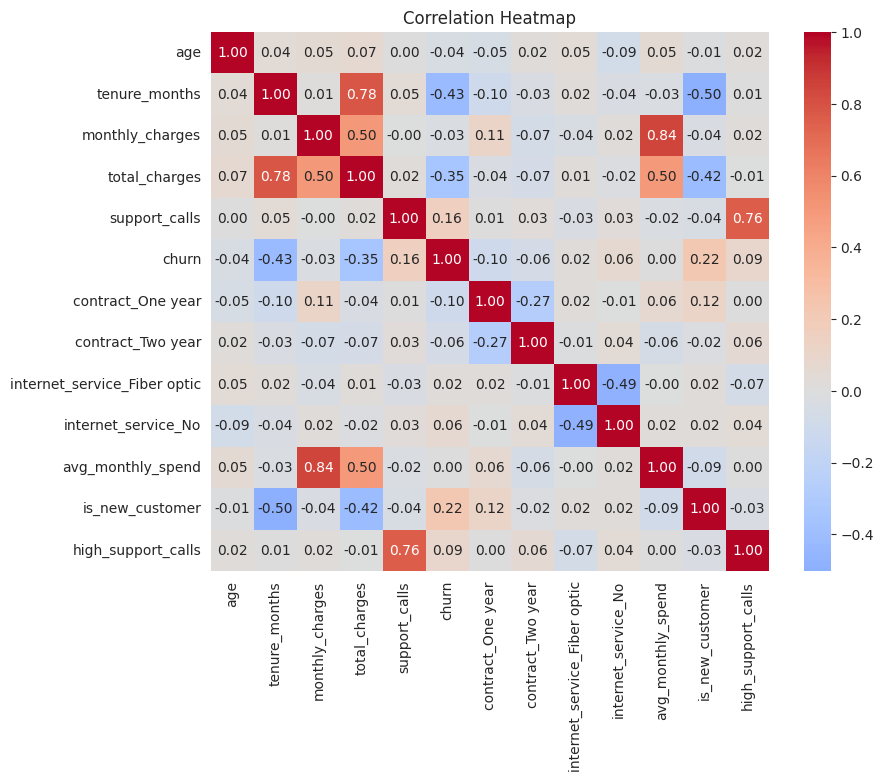

In [27]:
plt.figure(figsize=(9, 7))
corr = df_fe.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### Time Series Data Visualization

Let's simulate a small **synthetic monthly revenue** time series (trend + seasonality + noise) —
a common pattern you'll also see in Module 6 (Forecasting).


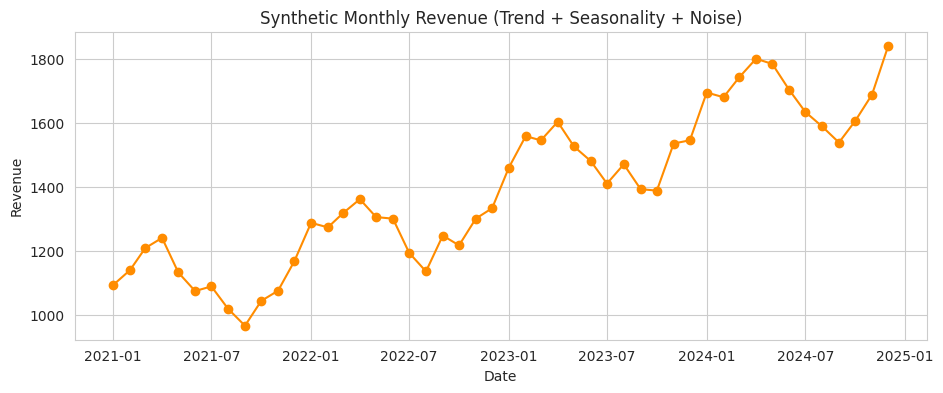

In [28]:
dates = pd.date_range("2021-01-01", periods=48, freq="MS")
trend = np.linspace(1000, 1800, 48)
seasonality = 150 * np.sin(2 * np.pi * dates.month / 12)
noise = np.random.normal(0, 40, 48)
revenue = trend + seasonality + noise

ts = pd.DataFrame({"date": dates, "revenue": revenue}).set_index("date")

plt.figure(figsize=(11, 4))
plt.plot(ts.index, ts["revenue"], marker="o", color="darkorange")
plt.title("Synthetic Monthly Revenue (Trend + Seasonality + Noise)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


---
## 1.3 Model Evaluation

We'll train a quick baseline `LogisticRegression` model on the churn data so we have real
predictions to evaluate with every metric below.


In [29]:
X = df_fe.drop(columns=["churn"])
y = df_fe["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Baseline accuracy:", round(accuracy_score(y_test, y_pred), 3))


Baseline accuracy: 0.736


### Confusion Matrix, Precision, Recall, F1-Score

- **Precision**: of everyone we predicted would churn, how many actually did?
- **Recall**: of everyone who actually churned, how many did we catch?
- **F1-score**: harmonic mean of precision and recall — useful when classes are imbalanced.


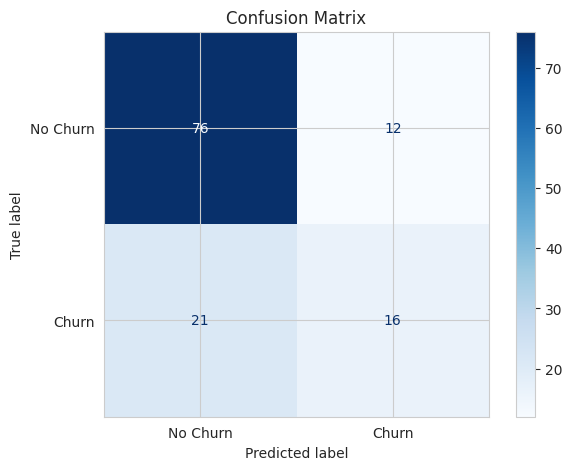

Precision: 0.571
Recall:    0.432
F1-score:  0.492

Full report:
               precision    recall  f1-score   support

    No Churn       0.78      0.86      0.82        88
       Churn       0.57      0.43      0.49        37

    accuracy                           0.74       125
   macro avg       0.68      0.65      0.66       125
weighted avg       0.72      0.74      0.72       125



In [30]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print("\nFull report:\n", classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


### AUC-ROC Curve

The ROC curve plots True Positive Rate vs False Positive Rate at every possible threshold.
AUC (Area Under Curve) close to **1.0** = excellent separation; **0.5** = no better than random guessing.


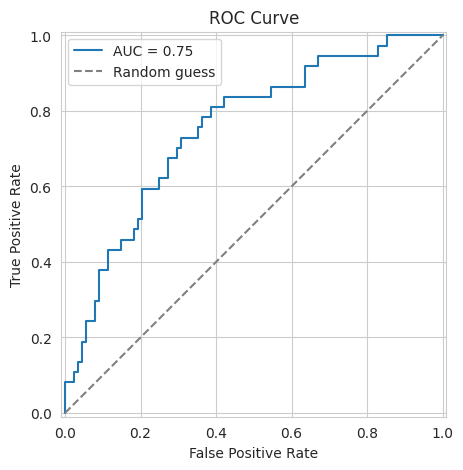

AUC score: 0.753


In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC score: {auc:.3f}")


### Cross-Validation

A single train/test split can be lucky or unlucky. **K-Fold Cross-Validation** trains/evaluates the
model K times on different splits and averages the results for a more reliable estimate.


In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline_model, scaler.fit_transform(X), y, cv=cv, scoring="accuracy")

print("Fold accuracies:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})")


Fold accuracies: [0.75 0.77 0.83 0.73 0.76]
Mean CV accuracy: 0.768  (± 0.034)


### Hyperparameter Tuning (GridSearchCV)

`GridSearchCV` exhaustively tries every combination of hyperparameters you give it (with
cross-validation baked in) and returns the best one.

*(Note: `Regularization` — the `C` parameter below controls it for Logistic Regression — is
covered again in the Linear/Logistic Regression sections of Module 2.)*


In [33]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="f1"
)
grid_search.fit(scaler.fit_transform(X_train), y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV F1-score: {grid_search.best_score_:.3f}")


Best hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.595


---
# 🧠 Module 2: Supervised Learning

Supervised learning has two flavors:
- **Regression** — predict a continuous number (e.g. house price).
- **Classification** — predict a discrete category (e.g. spam / not spam).

For each algorithm below we generate a **fresh synthetic dataset** shaped to best show off that
algorithm, train it, visualize it, and evaluate it.


## 2.1 Linear Regression

**Synthetic dataset:** predict a house's price from its size (sq. ft.) — a simple linear
relationship with some noise.


Coefficient (price per sq ft): 65.53
Intercept: 152795.03
R² score: 0.881
RMSE: 8890.71


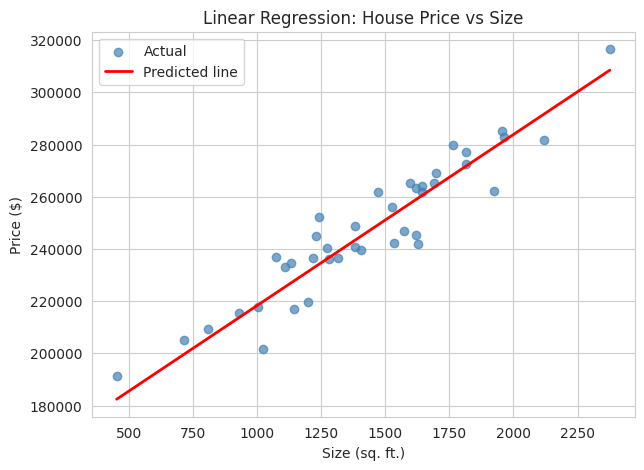

In [34]:
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=25, random_state=RANDOM_STATE)
X_reg_df = pd.DataFrame(X_reg, columns=["size_scaled"])
# Rescale into a human-readable "square feet" and "price" for intuition
size_sqft = (X_reg_df["size_scaled"] * 400 + 1500).round(0)
price = (y_reg * 300 + 250000 + np.random.normal(0, 5000, len(y_reg))).round(0)

house_df = pd.DataFrame({"size_sqft": size_sqft, "price": price})

X_train, X_test, y_train, y_test = train_test_split(
    house_df[["size_sqft"]], house_df["price"], test_size=0.2, random_state=RANDOM_STATE
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print(f"Coefficient (price per sq ft): {lin_reg.coef_[0]:.2f}")
print(f"Intercept: {lin_reg.intercept_:.2f}")
print(f"R² score: {r2_score(y_test, y_pred):.3f}")
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"RMSE: {rmse:.2f}")

plt.scatter(X_test, y_test, color="steelblue", label="Actual", alpha=0.7)
plt.plot(X_test.sort_values("size_sqft"), lin_reg.predict(X_test.sort_values("size_sqft")),
         color="red", linewidth=2, label="Predicted line")
plt.xlabel("Size (sq. ft.)")
plt.ylabel("Price ($)")
plt.title("Linear Regression: House Price vs Size")
plt.legend()
plt.show()


**🧪 Try it yourself:** Increase `noise=25` to `noise=80` in the `make_regression` call above and
re-run — watch R² drop as the relationship gets noisier.


## 2.2 Logistic Regression

**Synthetic dataset:** predict pass/fail on an exam from hours studied — a classic binary
classification example.


Accuracy: 0.950


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


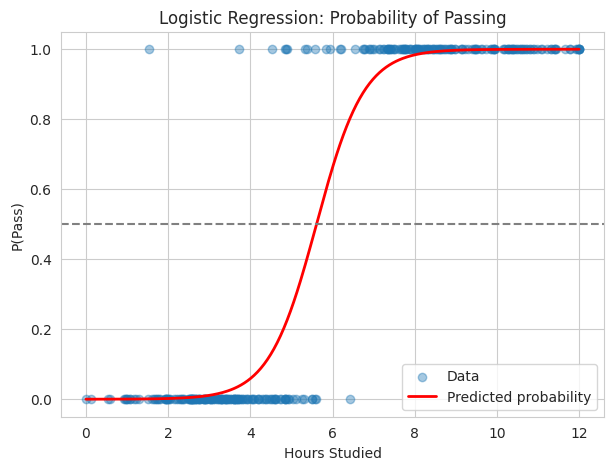

In [35]:
X_clf, y_clf = make_classification(
    n_samples=300, n_features=1, n_informative=1, n_redundant=0,
    n_clusters_per_class=1, random_state=RANDOM_STATE
)
hours_studied = (X_clf[:, 0] * 3 + 6).clip(0, 12)
exam_df = pd.DataFrame({"hours_studied": hours_studied, "passed": y_clf})

X_train, X_test, y_train, y_test = train_test_split(
    exam_df[["hours_studied"]], exam_df["passed"], test_size=0.2, random_state=RANDOM_STATE
)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Plot the sigmoid decision curve
x_range = np.linspace(0, 12, 300).reshape(-1, 1)
y_curve = log_reg.predict_proba(x_range)[:, 1]

plt.scatter(exam_df["hours_studied"], exam_df["passed"], alpha=0.4, label="Data")
plt.plot(x_range, y_curve, color="red", linewidth=2, label="Predicted probability")
plt.axhline(0.5, linestyle="--", color="gray")
plt.xlabel("Hours Studied")
plt.ylabel("P(Pass)")
plt.title("Logistic Regression: Probability of Passing")
plt.legend()
plt.show()


### Cost Function intuition

Logistic Regression is trained by minimizing **log loss** (cross-entropy), which heavily penalizes
confident-but-wrong predictions. Let's visualize that penalty curve.


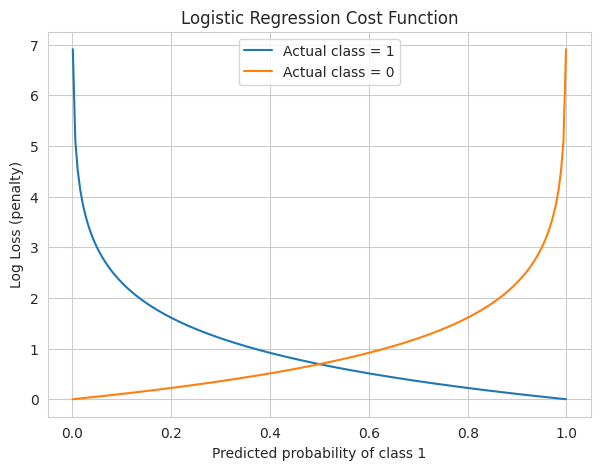

In [36]:
p = np.linspace(0.001, 0.999, 200)
loss_if_true_1 = -np.log(p)
loss_if_true_0 = -np.log(1 - p)

plt.plot(p, loss_if_true_1, label="Actual class = 1")
plt.plot(p, loss_if_true_0, label="Actual class = 0")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Log Loss (penalty)")
plt.title("Logistic Regression Cost Function")
plt.legend()
plt.show()


## 2.3 Decision Trees

**Synthetic dataset:** 2D clusters so we can visualize the tree's decision boundary.


Accuracy: 0.987


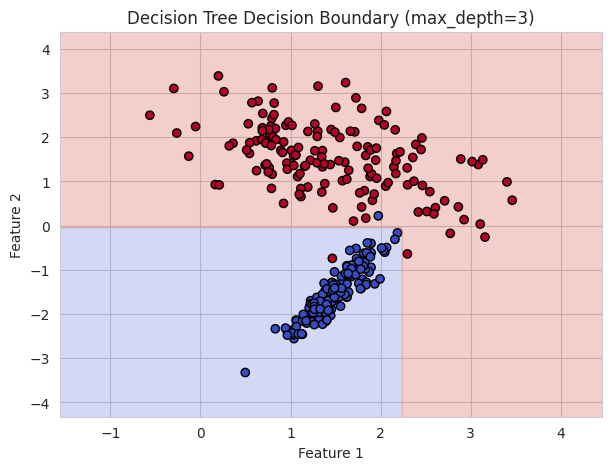

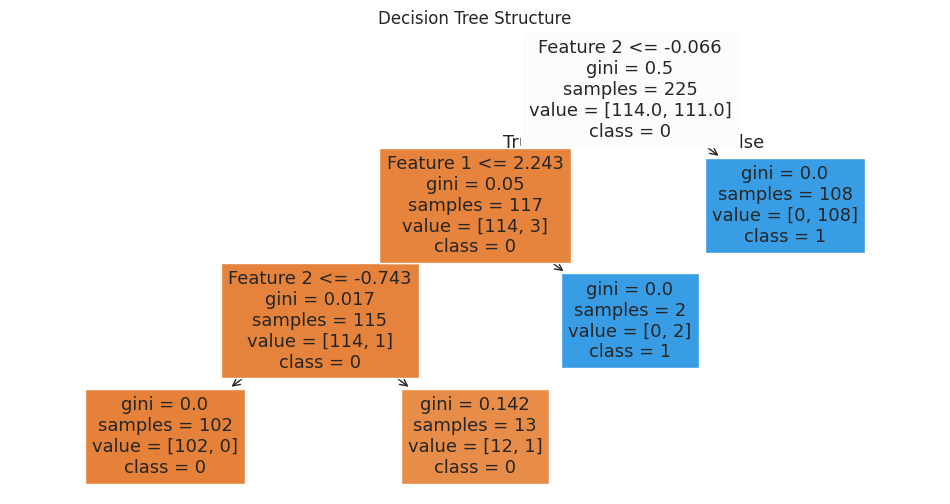

In [37]:
X_tree, y_tree = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(X_tree, y_tree, test_size=0.25, random_state=RANDOM_STATE)

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(tree_clf, X_tree, y_tree, "Decision Tree Decision Boundary (max_depth=3)")

plt.figure(figsize=(12, 6))
plot_tree(tree_clf, filled=True, feature_names=["Feature 1", "Feature 2"], class_names=["0", "1"])
plt.title("Decision Tree Structure")
plt.show()


**🧪 Try it yourself:** Set `max_depth=None` (unlimited depth) and re-run — notice how the boundary
becomes jagged. That's **overfitting**, and it's exactly why we prune trees or use ensembles like
Random Forest (see 2.7).


## 2.4 Support Vector Machines (SVM)

**Synthetic dataset:** two overlapping blobs — great for showing how SVM finds the maximum-margin
boundary, plus what happens with non-linear kernels.


Linear kernel accuracy: 1.0
RBF kernel accuracy: 1.0


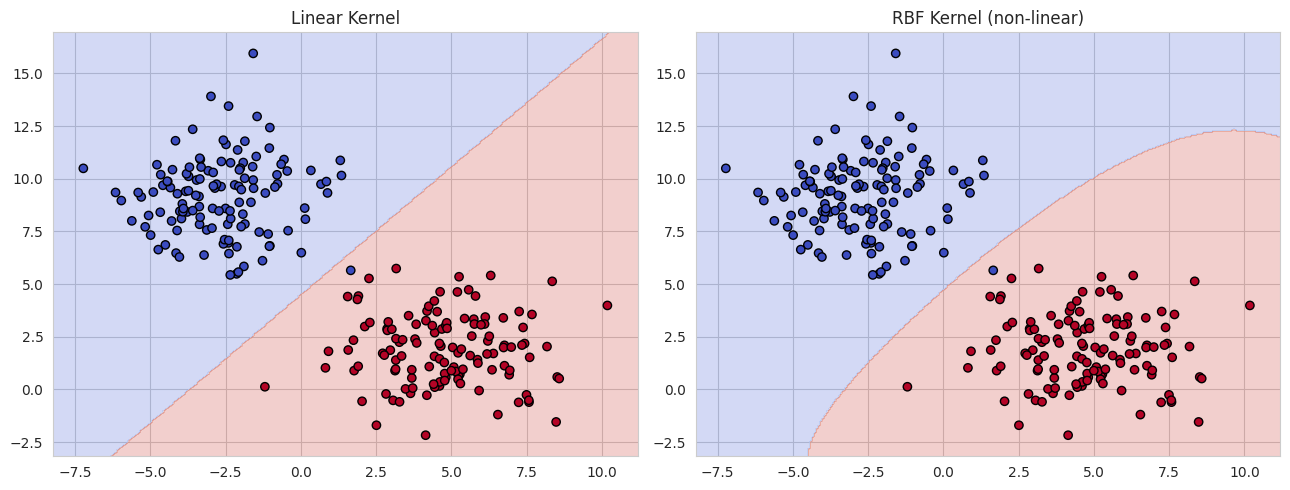

In [38]:
X_svm, y_svm = make_blobs(n_samples=250, centers=2, cluster_std=1.8, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(X_svm, y_svm, test_size=0.25, random_state=RANDOM_STATE)

svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)
print("Linear kernel accuracy:", round(accuracy_score(y_test, svm_linear.predict(X_test)), 3))

svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)
print("RBF kernel accuracy:", round(accuracy_score(y_test, svm_rbf.predict(X_test)), 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, title in zip(axes, [svm_linear, svm_rbf], ["Linear Kernel", "RBF Kernel (non-linear)"]):
    x_min, x_max = X_svm[:, 0].min() - 1, X_svm[:, 0].max() + 1
    y_min, y_max = X_svm[:, 1].min() - 1, X_svm[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_svm[:, 0], X_svm[:, 1], c=y_svm, cmap="coolwarm", edgecolor="k")
    ax.set_title(title)
plt.tight_layout()
plt.show()


### SVM Hyperparameter Tuning with GridSearchCV

The `C` parameter controls the margin/misclassification trade-off, and `gamma` controls how far the
influence of a single point reaches (for the RBF kernel).


In [39]:
param_grid = {"C": [0.1, 1, 10], "gamma": ["scale", 0.1, 1], "kernel": ["rbf"]}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")


Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.995


## 2.5 k-Nearest Neighbors (k-NN)

**Synthetic dataset:** three-cluster blobs — perfect for visualizing how the choice of `k` changes
the decision boundary.


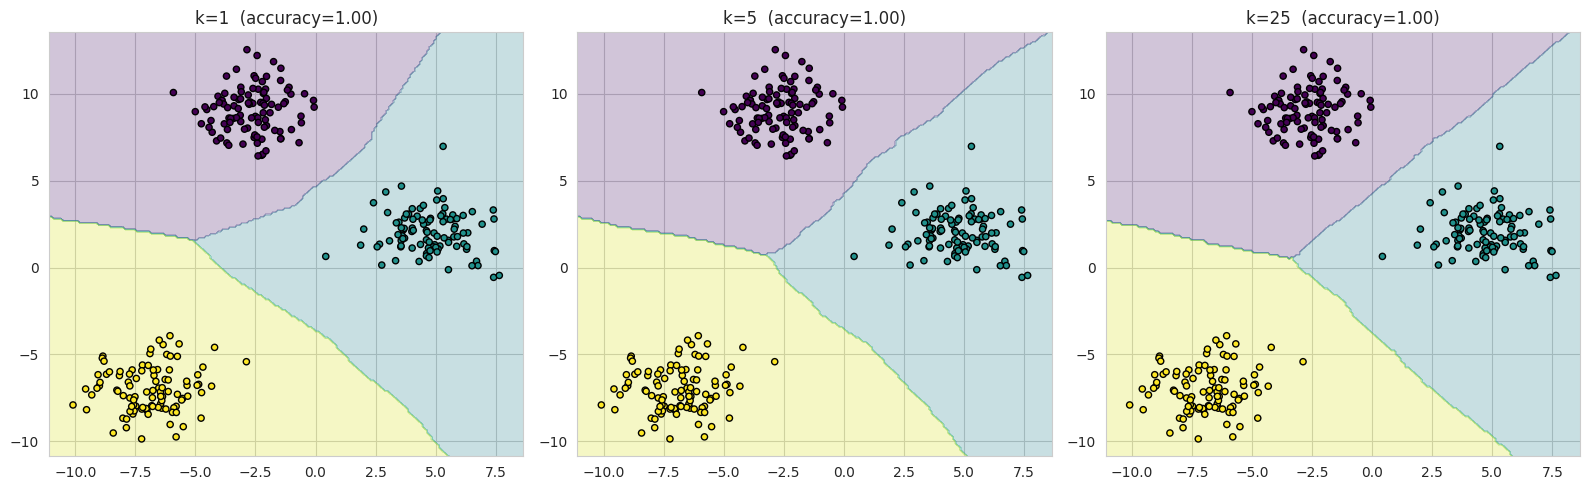

In [40]:
X_knn, y_knn = make_blobs(n_samples=300, centers=3, cluster_std=1.3, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.25, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k in zip(axes, [1, 5, 25]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))

    x_min, x_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
    y_min, y_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
    ax.scatter(X_knn[:, 0], X_knn[:, 1], c=y_knn, cmap="viridis", edgecolor="k", s=20)
    ax.set_title(f"k={k}  (accuracy={acc:.2f})")
plt.tight_layout()
plt.show()


Notice: **k=1** overfits (jagged boundary, memorizes noise), **k=25** underfits/oversmooths.
Choosing the right `k` is a classic bias–variance trade-off — the same idea GridSearchCV can help
tune, just like we did for SVM above.


## 2.6 Naïve Bayes

**Synthetic dataset:** a small "spam vs. not spam" style dataset using word-count-like features,
which is exactly the setting where Naïve Bayes shines in practice.


In [41]:
X_nb, y_nb = make_classification(
    n_samples=300, n_features=4, n_informative=3, n_redundant=1,
    weights=[0.7, 0.3], random_state=RANDOM_STATE
)
feature_names = ["freq_word_free", "freq_word_offer", "num_links", "capitalized_word_ratio"]
spam_df = pd.DataFrame(X_nb, columns=feature_names)
spam_df["is_spam"] = y_nb

X_train, X_test, y_train, y_test = train_test_split(
    spam_df[feature_names], spam_df["is_spam"], test_size=0.25, random_state=RANDOM_STATE
)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"]))


Accuracy: 0.880
              precision    recall  f1-score   support

    Not Spam       0.88      0.96      0.92        53
        Spam       0.88      0.68      0.77        22

    accuracy                           0.88        75
   macro avg       0.88      0.82      0.84        75
weighted avg       0.88      0.88      0.88        75



## 2.7 Random Forest (Bagging Algorithm)

**Synthetic dataset:** reuse the same customer churn data from Module 1 so we can directly compare
Random Forest against our earlier Logistic Regression baseline.


Random Forest accuracy: 0.688
Logistic Regression accuracy (from Module 1): 0.736


/tmp/ipykernel_1265/4171478976.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


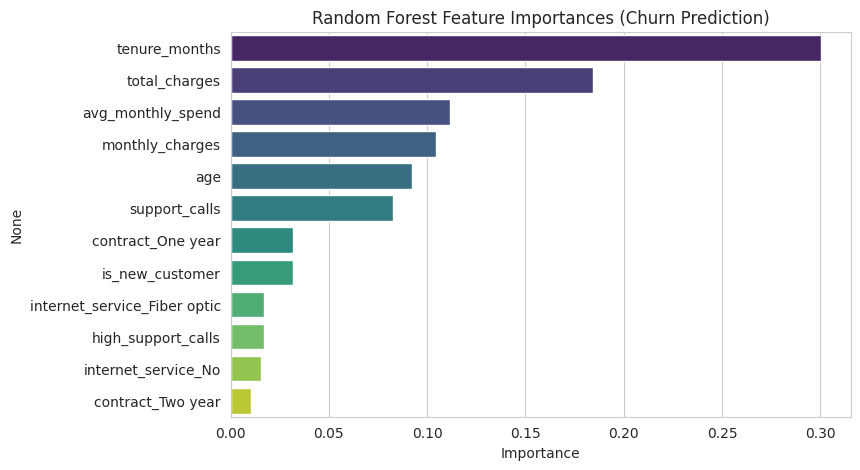

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
lr_acc = accuracy_score(y_test, baseline_model.predict(scaler.transform(X_test)))

print(f"Random Forest accuracy: {rf_acc:.3f}")
print(f"Logistic Regression accuracy (from Module 1): {lr_acc:.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest Feature Importances (Churn Prediction)")
plt.xlabel("Importance")
plt.show()


### Hyperparameter Tuning for Random Forest


In [43]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, None],
    "min_samples_split": [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid, cv=3, scoring="f1")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1-score: {grid.best_score_:.3f}")


Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.589


## 2.8 Ensemble Learning: Bagging vs. Boosting

- **Bagging** (e.g. Random Forest above, or `BaggingClassifier`): trains many models **independently**
  on random subsets of data, then averages/votes. Reduces variance.
- **Boosting** (e.g. AdaBoost, Gradient Boosting): trains models **sequentially**, each one focusing
  on the mistakes of the previous one. Reduces bias.

Let's compare all three on the same train/test split.


In [44]:
models = {
    "Bagging (base=Decision Tree)": BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                                                        n_estimators=100, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "F1-score": f1_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T.round(3)
results_df


,Accuracy,F1-score
Bagging (base=Decision Tree),0.696,0.424
AdaBoost,0.688,0.480
Gradient Boosting,0.656,0.394


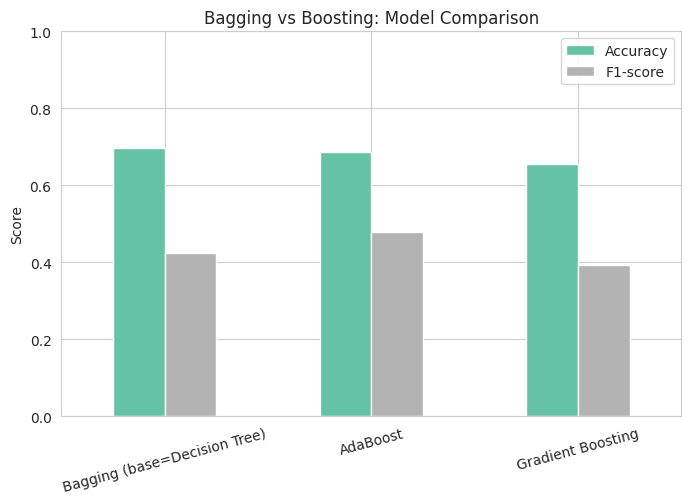

In [45]:
results_df.plot(kind="bar", figsize=(8, 5), colormap="Set2")
plt.title("Bagging vs Boosting: Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()


---
## ✅ Recap

**Module 1 — Pipeline:** we took a messy synthetic customer dataset through cleaning → encoding →
scaling → feature engineering/selection → EDA → and evaluated a baseline model with confusion
matrices, precision/recall/F1, ROC-AUC, cross-validation, and grid-search tuning.

**Module 2 — Supervised Learning:** we trained and visualized Linear Regression, Logistic Regression,
Decision Trees, SVM, k-NN, Naïve Bayes, Random Forest, and compared Bagging vs. Boosting ensembles —
each on a synthetic dataset shaped to highlight that algorithm's strengths.

